In [7]:
# %%
# ==============================================================
# 1. Imports & notebook settings (WebSky kSZ)
# ==============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.io import fits
import pickle
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 0,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "font.family": "DejaVu Sans",
    "text.usetex": False,           # <-- Keep False
    "mathtext.fontset": "dejavusans"  # or "cm", "stix"})
})

# ------------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------------
BASE_DIR = os.path.expanduser("~/Desktop/Project2/Plots/WebSky_Maps")
OUT_DIR = os.path.join(BASE_DIR, "output_WebSky_kSZ")
os.makedirs(OUT_DIR, exist_ok=True)

KSZ_FILES = {
    'ksz': 'ksz.fits',           # Homogeneous reionization
}

print(f"Output will be saved to: {OUT_DIR}")

Output will be saved to: /home/swanith/Desktop/Project2/Plots/WebSky_Maps/output_WebSky_kSZ


In [2]:
# %%
# ==============================================================
# 2. Diagnose FITS structure
# ==============================================================

def diagnose_fits_structure(fname):
    print("\n" + "="*70)
    print(f"DIAGNOSING: {os.path.basename(fname)}")
    print("="*70)
    
    with fits.open(fname) as hdul:
        print(f"\nNumber of HDUs: {len(hdul)}")
        hdul.info()
        
        for i, hdu in enumerate(hdul):
            print(f"\n--- HDU {i}: {hdu.name} ---")
            print(f"Type: {type(hdu)}")
            
            if hasattr(hdu, 'header'):
                print("\nKey header keywords:")
                for key in ['NSIDE', 'ORDERING', 'COORDSYS', 'PIXTYPE',
                           'TTYPE1', 'TUNIT1', 'TFIELDS', 'EXTNAME']:
                    if key in hdu.header:
                        print(f"  {key}: {hdu.header[key]}")
            
            if hasattr(hdu, 'data') and hdu.data is not None:
                if hasattr(hdu.data, 'columns'):
                    print(f"\nColumn names: {hdu.data.columns.names}")
                    for col in hdu.data.columns:
                        print(f"  - {col.name} ({col.format})")
                elif isinstance(hdu.data, np.ndarray):
                    print(f"\nData shape: {hdu.data.shape}")
                    print(f"Data dtype: {hdu.data.dtype}")

# Run for each file
for name, fname in KSZ_FILES.items():
    fpath = os.path.join(BASE_DIR, fname)
    if os.path.isfile(fpath):
        diagnose_fits_structure(fpath)
    else:
        print(f"Skipping {fname} — not found")


DIAGNOSING: ksz.fits

Number of HDUs: 2
Filename: /home/swanith/Desktop/Project2/Plots/WebSky_Maps/ksz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   196608R x 1C   [1024E]   

--- HDU 0: PRIMARY ---
Type: <class 'astropy.io.fits.hdu.image.PrimaryHDU'>

Key header keywords:

--- HDU 1: xtension ---
Type: <class 'astropy.io.fits.hdu.table.BinTableHDU'>

Key header keywords:
  NSIDE: 4096
  ORDERING: RING
  PIXTYPE: HEALPIX
  TTYPE1: T
  TFIELDS: 1
  EXTNAME: xtension

Column names: ['T']
  - T (1024E)


In [3]:
# %%
# ==============================================================
# 3. Load kSZ map (supports multi-dim data)
# ==============================================================

def load_fits_data(fname):
    print("\n" + "="*70)
    print(f"LOADING: {os.path.basename(fname)}")
    print("="*70)
    
    with fits.open(fname) as hdul:
        if len(hdul) > 1 and hasattr(hdul[1].data, 'columns'):
            col_names = hdul[1].data.columns.names
            print(f"Available columns: {col_names}")
            
            possible = ['TEMPERATURE', 'I_STOKES', 'SIGNAL', 'PIXELS', 'T']
            for name in possible:
                if name in col_names:
                    print(f"Using column: {name}")
                    data = hdul[1].data[name]
                    hdr = hdul[1].header
                    break
            else:
                name = col_names[0]
                print(f"Using first column: {name}")
                data = hdul[1].data[name]
                hdr = hdul[1].header
            
            if data.ndim > 1:
                print(f"Flattening {data.shape} → {data.size} pixels")
                data = data.flatten()
            
            nside = hp.npix2nside(len(data))
            print(f"Valid HEALPix: NSIDE={nside}, NPIX={len(data)}")
            return data, hdr, name
        
        elif isinstance(hdul[0].data, np.ndarray):
            data = hdul[0].data.flatten()
            hdr = hdul[0].header
            nside = hp.npix2nside(len(data))
            return data, hdr, "IMAGE"
        
        else:
            raise ValueError("Unknown FITS structure")

# Load all maps
maps = {}
for name, fname in KSZ_FILES.items():
    fpath = os.path.join(BASE_DIR, fname)
    if os.path.isfile(fpath):
        data, hdr, col = load_fits_data(fpath)
        maps[name] = {'data': data, 'hdr': hdr, 'col': col}
    else:
        print(f"Skipping {fname}")


LOADING: ksz.fits
Available columns: ['T']
Using column: T
Flattening (196608, 1024) → 201326592 pixels
Valid HEALPix: NSIDE=4096, NPIX=201326592


In [4]:
# %%
# ==============================================================
# 4. Analyze pixel statistics
# ==============================================================

def analyze_map(data, name):
    print(f"\n" + "="*70)
    print(f"ANALYZING: {name.upper()}")
    print("="*70)
    
    stats = {
        'min': data.min(),
        'max': data.max(),
        'mean': data.mean(),
        'std': data.std(),
        'median': np.median(data),
        'rms': np.sqrt(np.mean(data**2))
    }
    
    print("\nStatistics (µK):")
    for k, v in stats.items():
        print(f"  {k:8s}: {v:.6e}")
    
    return stats

stats_dict = {}
for name, info in maps.items():
    stats_dict[name] = analyze_map(info['data'], name)


ANALYZING: KSZ

Statistics (µK):
  min     : -8.129686e+01
  max     : 7.365024e+01
  mean    : -1.865582e-01
  std     : 3.380176e+00
  median  : -1.691572e-01
  rms     : 3.385323e+00


<Figure size 1600x800 with 0 Axes>

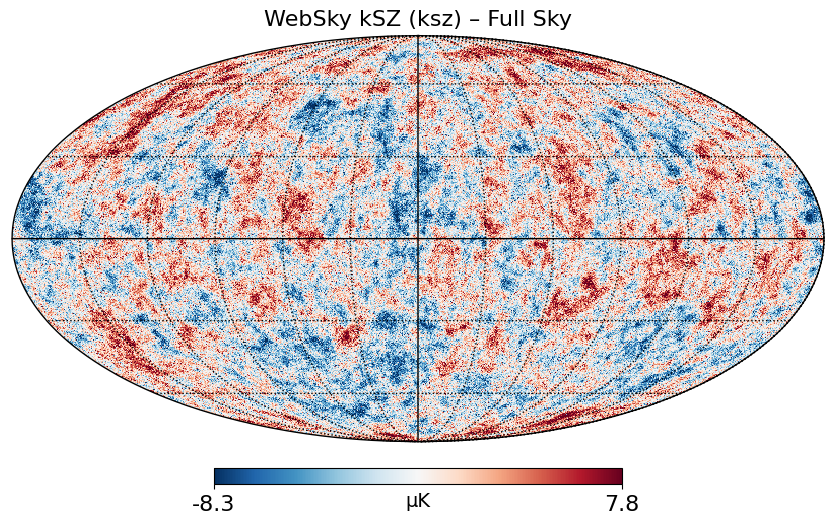

Saved: /home/swanith/Desktop/Project2/Plots/WebSky_Maps/output_WebSky_kSZ/ksz_mollweide.pdf


In [8]:
# %%
# ==============================================================
# 5. Mollweide full-sky maps
# ==============================================================

for name, info in maps.items():
    data = info['data']
    vmin, vmax = np.percentile(data, [1, 99])
    nside = hp.npix2nside(len(data))

    plt.figure(figsize=(16, 8))
    hp.mollview(
        data,
        title=f'WebSky kSZ ({name}) – Full Sky',
        unit='µK',
        cmap='RdBu_r',
        min=vmin, max=vmax,
        format='%.1f'
    )
    hp.graticule()
    ax = plt.gca()
    ax.title.set_fontsize(16)

    path = os.path.join(OUT_DIR, f"{name}_mollweide.pdf")
    plt.savefig(path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")


Histogram + Gaussian: KSZ
  → μ = -0.187 µK, σ = 3.380 µK


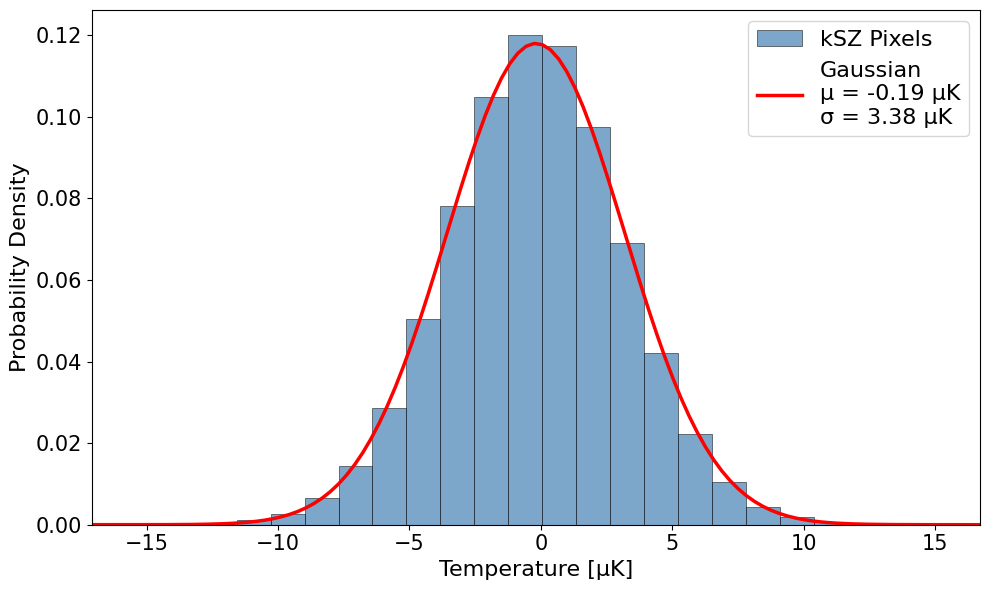

Saved: /home/swanith/Desktop/Project2/Plots/WebSky_Maps/output_WebSky_kSZ/ksz_histogram_gaussian.pdf


In [13]:
# %%
# ==============================================================
# 7. Histogram with Gaussian overlay (using map mean & std)
# ==============================================================

for name, info in maps.items():
    print(f"\nHistogram + Gaussian: {name.upper()}")
    
    data = info['data']
    values = data.compressed() if np.ma.is_masked(data) else np.array(data)
    if len(values) == 0:
        print("  → Empty map, skipping histogram")
        continue
    
    mu = np.mean(values)
    sigma = np.std(values)
    print(f"  → μ = {mu:+.3f} µK, σ = {sigma:.3f} µK")
    
    plt.figure(figsize=(10, 6))
    plt.hist(values, bins=120, density=True, alpha=0.7, color='steelblue',
             edgecolor='black', linewidth=0.5, label='kSZ Pixels')
    
    x_gauss = np.linspace(values.min(), values.max(), 500)
    y_gauss = (1 / (sigma * np.sqrt(2 * np.pi))) * \
              np.exp(-0.5 * ((x_gauss - mu) / sigma)**2)
    plt.plot(x_gauss, y_gauss, 'r-', lw=2.5,
             label=f'Gaussian\nμ = {mu:+.2f} µK\nσ = {sigma:.2f} µK')
    
    plt.xlabel('Temperature [µK]', fontsize=16)
    plt.ylabel('Probability Density', fontsize=16)
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.xlim(mu - 5*sigma, mu + 5*sigma)
    plt.legend(fontsize=16, frameon=True, fancybox=True, loc='upper right')
    plt.tight_layout()
    
    path = os.path.join(OUT_DIR, f"{name}_histogram_gaussian.pdf")
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")


Power spectrum: KSZ
  → Loading cached C_ℓ


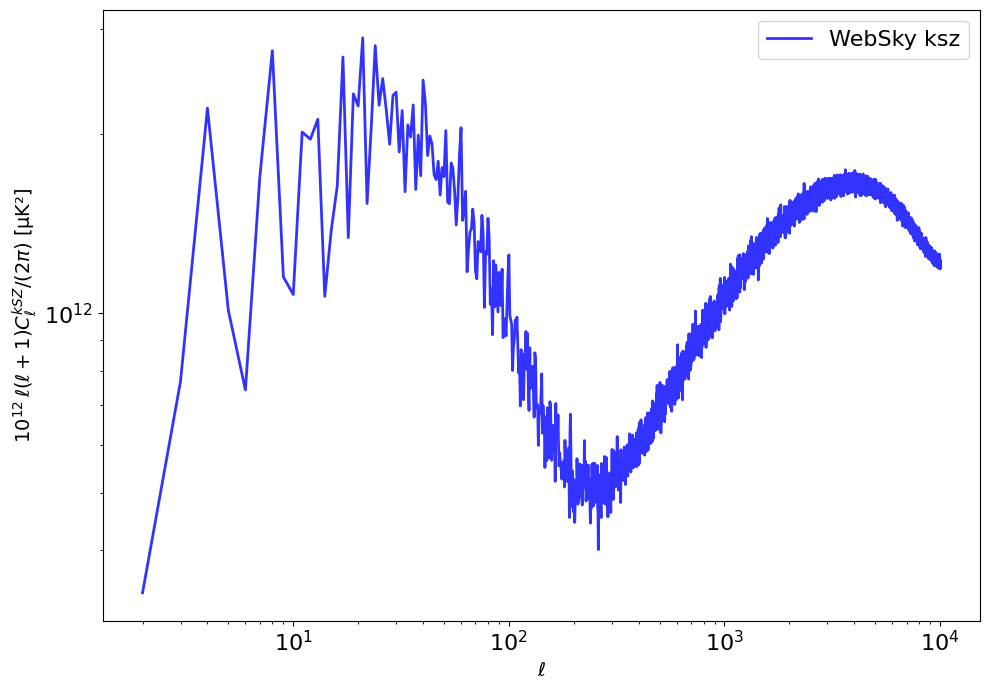

Saved: /home/swanith/Desktop/Project2/Plots/WebSky_Maps/output_WebSky_kSZ/ksz_powerspectrum.pdf
Saved data: /home/swanith/Desktop/Project2/Plots/WebSky_Maps/output_WebSky_kSZ/ksz_powerspectrum_data.txt


In [10]:
# %%
# ==============================================================
# 6. Power spectrum (cached + toggle)
# ==============================================================

cache_dir = Path(OUT_DIR) / "cache"
cache_dir.mkdir(exist_ok=True)

force_recalculate = False

for name, info in maps.items():
    data = info['data']
    nside = hp.npix2nside(len(data))
    cache_file = cache_dir / f"{name}_powerspectrum_cl.pkl"

    print(f"\nPower spectrum: {name.upper()}")

    if force_recalculate or not cache_file.exists():
        print("  → Computing C_ℓ...")
        lmax = min(3*nside - 1, 10000)
        cl = hp.anafast(data, lmax=lmax)
        ell = np.arange(len(cl))
        with open(cache_file, 'wb') as f:
            pickle.dump(cl, f)
        print(f"  → Cached: {cache_file}")
    else:
        print(f"  → Loading cached C_ℓ")
        with open(cache_file, 'rb') as f:
            cl = pickle.load(f)
        ell = np.arange(len(cl))

    Dl = ell * (ell + 1) * cl / (2 * np.pi)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.plot(ell[2:], Dl[2:] * 1e12, 'b-', lw=2, label=f'WebSky {name}', alpha=0.8)
    ax.set_xscale('log')
    ax.set_yscale('log')
    #ax.set_xlim(10, 10000)
    #ax.set_ylim(1e-4, 10)
    ax.set_xlabel(r'$\ell$', fontsize=14)
    ax.set_ylabel(r'$10^{12} \, \ell(\ell+1) C_\ell^{kSZ} / (2\pi)$ [µK²]', fontsize=14)
    #ax.set_title(f'WebSky kSZ ({name}) Angular Power Spectrum', fontsize=15)
    #ax.grid(True, which='both', alpha=0.3)
    ax.legend()

    plt.tight_layout()
    ps_path = os.path.join(OUT_DIR, f"{name}_powerspectrum.pdf")
    plt.savefig(ps_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved: {ps_path}")

    # Save data
    txt_path = os.path.join(OUT_DIR, f"{name}_powerspectrum_data.txt")
    np.savetxt(txt_path, np.column_stack([ell, cl, Dl, Dl*1e12]),
               header='ell  C_ell  D_ell  D_ell_x1e12', fmt='%.6e')
    print(f"Saved data: {txt_path}")